In [1]:
# celda 1

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import nltk
import torch
import torch.nn as nn

from collections import Counter
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from spacy.tokens import Doc
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Versión de PyTorch:", torch.__version__)
print("Versión de NLTK:", nltk.__version__)


Versión de PyTorch: 2.14.1
Versión de NLTK: 3.10.0


# Sección 1: redes multicapa con nn.Module

In [2]:
# celda 2

entradas_xor = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

salidas_xor = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])


class MLP(nn.Module):

    def __init__(self, dimension_entrada, dimension_oculta,
                 dimension_salida, usar_activacion=True):
        super().__init__()

        self.capa_oculta = nn.Linear(dimension_entrada, dimension_oculta)
        self.activacion = nn.Tanh()
        self.capa_salida = nn.Linear(dimension_oculta, dimension_salida)
        self.usar_activacion = usar_activacion

    def forward(self, entrada):
        resultado_oculta = self.capa_oculta(entrada)

        # si usar_activacion es False, se salta la tanh
        if self.usar_activacion:
            resultado_oculta = self.activacion(resultado_oculta)

        return self.capa_salida(resultado_oculta)


In [3]:
# celda 3

def contar_parametros(modelo):
    return sum(parametro.numel() for parametro in modelo.parameters())


def entrenar_xor(modelo, epocas=2000, tasa_aprendizaje=0.05):
    funcion_perdida = nn.BCEWithLogitsLoss()
    optimizador = torch.optim.Adam(
        modelo.parameters(),
        lr=tasa_aprendizaje
    )

    historial_perdida = []

    for epoca in range(epocas):
        salida = modelo(entradas_xor)
        perdida = funcion_perdida(salida, salidas_xor)

        optimizador.zero_grad()
        perdida.backward()
        optimizador.step()

        historial_perdida.append(perdida.item())

    return historial_perdida


def exactitud_xor(modelo):
    modelo.eval()

    with torch.no_grad():
        predicciones = (modelo(entradas_xor) > 0).float()

    return (predicciones == salidas_xor).float().mean().item()


def graficar_frontera(modelo, titulo, ejes):
    malla_x1, malla_x2 = np.meshgrid(
        np.linspace(-0.5, 1.5, 200),
        np.linspace(-0.5, 1.5, 200)
    )

    puntos_malla = torch.tensor(
        np.c_[malla_x1.ravel(), malla_x2.ravel()],
        dtype=torch.float32
    )

    modelo.eval()

    with torch.no_grad():
        zona_predicha = (
            (modelo(puntos_malla) > 0)
            .float()
            .reshape(malla_x1.shape)
            .numpy()
        )

    ejes.contourf(
        malla_x1, malla_x2, zona_predicha,
        levels=[-0.5, 0.5, 1.5],
        cmap='coolwarm',
        alpha=0.3
    )

    ejes.scatter(
        entradas_xor[:, 0].numpy(),
        entradas_xor[:, 1].numpy(),
        c=salidas_xor.squeeze().numpy(),
        cmap='coolwarm',
        edgecolors='black',
        s=150
    )

    ejes.set_title(titulo)
    ejes.set_xlabel('Entrada 1')
    ejes.set_ylabel('Entrada 2')


In [ ]:
# celda 4


torch.manual_seed(42)
modelo_xor_con_activacion = MLP(2, 8, 1, usar_activacion=True)

historial_con_activacion = entrenar_xor(modelo_xor_con_activacion)

print("Pérdida final con activación:", round(historial_con_activacion[-1], 4))
print("Exactitud con activación:", exactitud_xor(modelo_xor_con_activacion) * 100, "%")

print()
print("Probabilidad que da la red para cada entrada:")
with torch.no_grad():
    probabilidades = torch.sigmoid(modelo_xor_con_activacion(entradas_xor))

for entrada, probabilidad in zip(entradas_xor, probabilidades):
    print(entrada.tolist(), "->", round(probabilidad.item(), 4))


Pérdida final con activación: 0.0
Exactitud con activación: 100.0 %

Probabilidad que da la red para cada entrada:
[0.0, 0.0] -> 0.0
[0.0, 1.0] -> 1.0
[1.0, 0.0] -> 1.0
[1.0, 1.0] -> 0.0


In [ ]:
# celda 5

torch.manual_seed(42)
modelo_xor_sin_activacion = MLP(2, 8, 1, usar_activacion=False)

historial_sin_activacion = entrenar_xor(modelo_xor_sin_activacion)

print("Pérdida final sin activación:", round(historial_sin_activacion[-1], 4))
print("Exactitud sin activación:", exactitud_xor(modelo_xor_sin_activacion) * 100, "%")

print()
print("Probabilidad que da la red para cada entrada:")
with torch.no_grad():
    probabilidades = torch.sigmoid(modelo_xor_sin_activacion(entradas_xor))

for entrada, probabilidad in zip(entradas_xor, probabilidades):
    print(entrada.tolist(), "->", round(probabilidad.item(), 4))


Pérdida final sin activación: 0.6931
Exactitud sin activación: 75.0 %

Probabilidad que da la red para cada entrada:
[0.0, 0.0] -> 0.5
[0.0, 1.0] -> 0.5
[1.0, 0.0] -> 0.5
[1.0, 1.0] -> 0.5


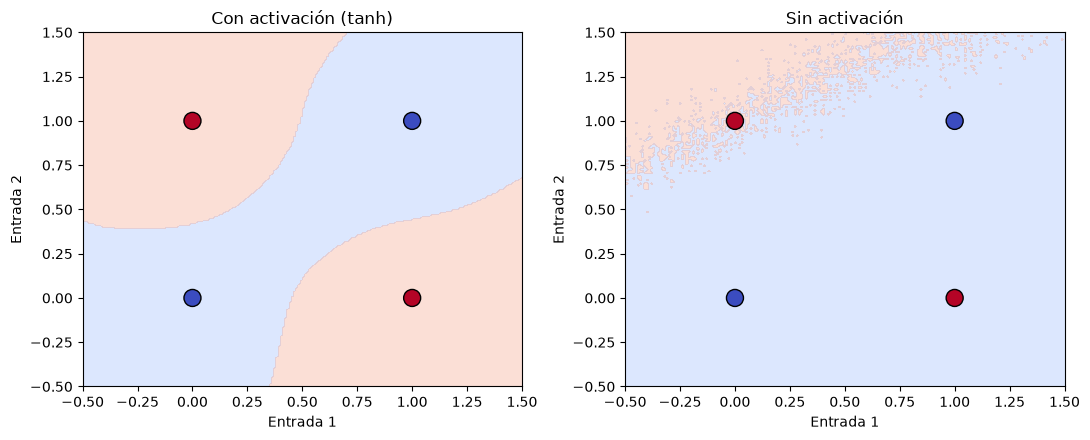

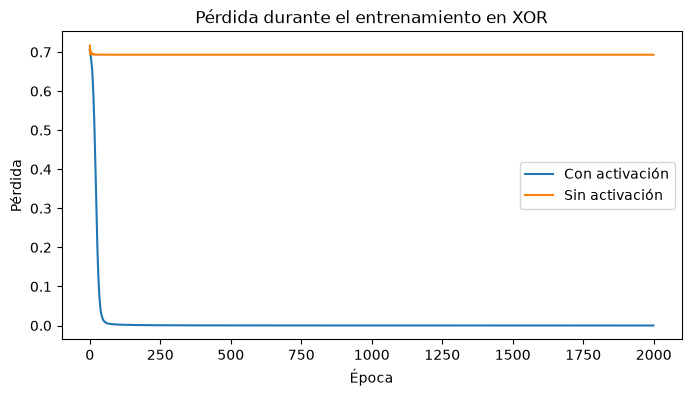

In [6]:
# celda 6

figura, ejes = plt.subplots(1, 2, figsize=(11, 4.5))

graficar_frontera(modelo_xor_con_activacion, 'Con activación (tanh)', ejes[0])
graficar_frontera(modelo_xor_sin_activacion, 'Sin activación', ejes[1])

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(historial_con_activacion, label='Con activación')
plt.plot(historial_sin_activacion, label='Sin activación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida durante el entrenamiento en XOR')
plt.legend()
plt.show()


In [ ]:
# celda 7

with torch.no_grad():
    pesos_capa_1 = modelo_xor_sin_activacion.capa_oculta.weight
    sesgos_capa_1 = modelo_xor_sin_activacion.capa_oculta.bias
    pesos_capa_2 = modelo_xor_sin_activacion.capa_salida.weight
    sesgos_capa_2 = modelo_xor_sin_activacion.capa_salida.bias

    pesos_equivalentes = pesos_capa_2 @ pesos_capa_1
    sesgo_equivalente = pesos_capa_2 @ sesgos_capa_1 + sesgos_capa_2

    salida_dos_capas = modelo_xor_sin_activacion(entradas_xor)
    salida_una_capa = entradas_xor @ pesos_equivalentes.T + sesgo_equivalente

    print("Forma de los pesos de la capa 1:", tuple(pesos_capa_1.shape))
    print("Forma de los pesos de la capa 2:", tuple(pesos_capa_2.shape))
    print("Forma de los pesos de la capa equivalente:", tuple(pesos_equivalentes.shape))
    print()
    print("Salida con las dos capas:")
    print(salida_dos_capas.squeeze())
    print("Salida con la única capa equivalente:")
    print(salida_una_capa.squeeze())
    print()
    print("¿Son iguales?:", torch.allclose(salida_dos_capas, salida_una_capa, atol=1e-5))


Forma de los pesos de la capa 1: (8, 2)
Forma de los pesos de la capa 2: (1, 8)
Forma de los pesos de la capa equivalente: (1, 2)

Salida con las dos capas:
tensor([-7.4506e-08,  1.4901e-08, -1.1921e-07, -7.4506e-08])
Salida con la única capa equivalente:
tensor([-7.4506e-08,  1.5753e-08, -1.2441e-07, -3.4152e-08])

¿Son iguales?: True


In [ ]:
# celda 8

class RedDiapositiva(nn.Module):

    def __init__(self):
        super().__init__()

        self.capa_oculta_1 = nn.Linear(3, 4)
        self.capa_oculta_2 = nn.Linear(4, 4)
        self.capa_salida = nn.Linear(4, 2)
        self.activacion = nn.ReLU()

    def forward(self, entrada):
        resultado = self.activacion(self.capa_oculta_1(entrada))
        resultado = self.activacion(self.capa_oculta_2(resultado))
        return self.capa_salida(resultado)


torch.manual_seed(42)
red_diapositiva = RedDiapositiva()

print(red_diapositiva)
print()
print("Total de parámetros:", contar_parametros(red_diapositiva))


RedDiapositiva(
  (capa_oculta_1): Linear(in_features=3, out_features=4, bias=True)
  (capa_oculta_2): Linear(in_features=4, out_features=4, bias=True)
  (capa_salida): Linear(in_features=4, out_features=2, bias=True)
  (activacion): ReLU()
)

Total de parámetros: 46


In [9]:
# celda 9

for nombre, parametro in red_diapositiva.named_parameters():
    print(f"{nombre:25s} forma: {str(tuple(parametro.shape)):10s} cantidad: {parametro.numel()}")


capa_oculta_1.weight      forma: (4, 3)     cantidad: 12
capa_oculta_1.bias        forma: (4,)       cantidad: 4
capa_oculta_2.weight      forma: (4, 4)     cantidad: 16
capa_oculta_2.bias        forma: (4,)       cantidad: 4
capa_salida.weight        forma: (2, 4)     cantidad: 8
capa_salida.bias          forma: (2,)       cantidad: 2



### Resultado del MLP en XOR y frontera de decisión

El MLP con la función de activación tanh logró resolver correctamente el problema XOR. Después del entrenamiento obtuvo una pérdida prácticamente de 0 y una exactitud del 100%. También se puede ver en las probabilidades que para las entradas [0,0] y [1,1] predice prácticamente 0, mientras que para [0,1] y [1,0] predice prácticamente 1.

Por otro lado, cuando se utilizó exactamente la misma red pero quitando la función de activación, el resultado fue bastante diferente. La pérdida quedó en 0.6931 y la exactitud fue de 75%. Además, la red da una probabilidad de aproximadamente 0.5 para las cuatro combinaciones de entrada, osea que realmente no logró aprender el patrón de XOR.

Esto también se puede observar en la frontera de decisión. Con la activación tanh la red logra crear una frontera no lineal que separa correctamente los cuatro puntos, mientras que sin activación no puede crear esa separación.


### ¿Por qué apilar capas lineales equivale a una sola capa lineal?

Apilar varias capas lineales sin poner una función de activación entre ellas realmente no hace que la red sea más expresiva. Esto pasa porque la salida de una capa lineal entra directamente a otra transformación lineal y al combinar ambas operaciones el resultado sigue siendo otra transformación lineal.

En este caso se comprobó directamente usando los pesos de las dos capas de la red sin activación. La primera capa tenía pesos de forma (8,2) y la segunda (1,8). Al multiplicarlos se obtiene una única matriz equivalente de forma (1,2). Las salidas calculadas usando las dos capas y usando una sola capa equivalente fueron prácticamente iguales, y torch.allclose() devolvió True.

Por lo tanto, aunque se agreguen más capas, si no existe una activación no lineal entre ellas la red sigue comportándose como una sola capa lineal. Por eso no puede resolver un problema como XOR, ya que XOR no se puede separar utilizando únicamente una frontera lineal.


### Parámetros de la red de la diapositiva y formas de pesos y sesgos

La red de la diapositiva tiene una entrada de 3 variables, dos capas ocultas de 4 neuronas cada una y una salida de 2 neuronas. En total tiene 46 parámetros entrenables.

Los parámetros quedaron distribuidos de la siguiente manera:

| Parámetro | Forma | Cantidad |
|---|---:|---:|
| capa_oculta_1.weight | (4, 3) | 12 |
| capa_oculta_1.bias | (4,) | 4 |
| capa_oculta_2.weight | (4, 4) | 16 |
| capa_oculta_2.bias | (4,) | 4 |
| capa_salida.weight | (2, 4) | 8 |
| capa_salida.bias | (2,) | 2 |

Esto suma un total de 46 parámetros entre pesos y sesgos.

# Sección 2: funciones de activación

In [10]:
# celda 10

z = torch.linspace(-5, 5, 200, requires_grad=True)

funciones_activacion = {
    'Sigmoide': torch.sigmoid(z),
    'Tanh': torch.tanh(z),
    'ReLU': torch.relu(z)
}

# autograd calcula la derivada de cada función respecto a z
# (se usa .sum() para que el resultado sea la derivada punto por punto)
derivadas_activacion = {}

for nombre, valores in funciones_activacion.items():
    derivada = torch.autograd.grad(valores.sum(), z, retain_graph=True)[0]
    derivadas_activacion[nombre] = derivada.detach().numpy()

valores_z = z.detach().numpy()

print("Derivadas calculadas para:", list(derivadas_activacion.keys()))


Derivadas calculadas para: ['Sigmoide', 'Tanh', 'ReLU']


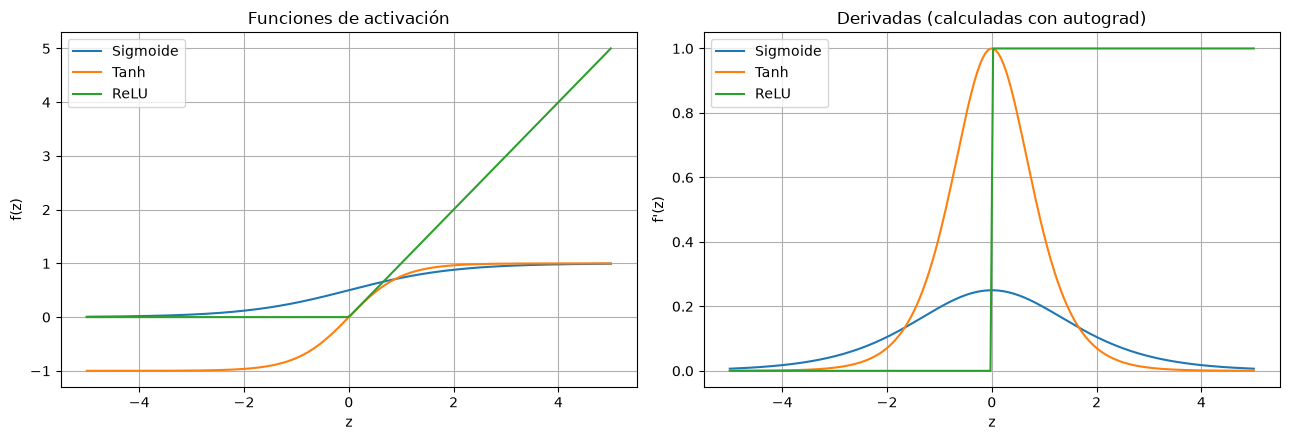

In [11]:
# celda 11

figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

for nombre, valores in funciones_activacion.items():
    ejes[0].plot(valores_z, valores.detach().numpy(), label=nombre)

ejes[0].set_title('Funciones de activación')
ejes[0].set_xlabel('z')
ejes[0].set_ylabel('f(z)')
ejes[0].legend()
ejes[0].grid(True)

for nombre, derivada in derivadas_activacion.items():
    ejes[1].plot(valores_z, derivada, label=nombre)

ejes[1].set_title('Derivadas (calculadas con autograd)')
ejes[1].set_xlabel('z')
ejes[1].set_ylabel("f'(z)")
ejes[1].legend()
ejes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# celda 12

umbral_gradiente = 0.05

for nombre, derivada in derivadas_activacion.items():
    mascara_pequena = derivada < umbral_gradiente
    zona_izquierda = valores_z[mascara_pequena & (valores_z < 0)]
    zona_derecha = valores_z[mascara_pequena & (valores_z > 0)]

    print(nombre)
    print("  Derivada máxima:", round(float(derivada.max()), 4))

    if len(zona_izquierda) > 0:
        print(f"  Derivada menor a {umbral_gradiente} cuando z es menor a {zona_izquierda.max():.2f}")
    if len(zona_derecha) > 0:
        print(f"  Derivada menor a {umbral_gradiente} cuando z es mayor a {zona_derecha.min():.2f}")
    print()


Sigmoide
  Derivada máxima: 0.25
  Derivada menor a 0.05 cuando z es menor a -2.89
  Derivada menor a 0.05 cuando z es mayor a 2.89

Tanh
  Derivada máxima: 0.9994
  Derivada menor a 0.05 cuando z es menor a -2.19
  Derivada menor a 0.05 cuando z es mayor a 2.19

ReLU
  Derivada máxima: 1.0
  Derivada menor a 0.05 cuando z es menor a -0.03



### ¿En qué regiones se desvanece el gradiente de la sigmoide y de tanh?

En las gráficas se puede observar que tanto la sigmoide como tanh tienen derivadas que se hacen cada vez más pequeñas cuando los valores de z se alejan de 0.

En la sigmoide, la derivada máxima solamente llega a 0.25 y usando como referencia una derivada menor a 0.05, el gradiente prácticamente se empieza a desvanecer cuando z < -2.89 o cuando z > 2.89.

En tanh pasa algo parecido. Su derivada puede llegar casi a 1 cerca de 0, pero se vuelve menor a 0.05 aproximadamente cuando z < -2.19 o z > 2.19.

Entonces, en ambas funciones el problema aparece principalmente en los extremos. Cuando la neurona se encuentra en esas regiones, su derivada es muy pequeña y por lo tanto durante backpropagation los pesos reciben actualizaciones cada vez menores.


### ¿Por qué ReLU es la opción por defecto en capas ocultas?

ReLU tiene una diferencia importante con sigmoide y tanh. Para valores positivos su derivada se mantiene en 1, por lo que no se va haciendo cada vez más pequeña conforme aumenta el valor de z. Esto ayuda a evitar el problema del desvanecimiento del gradiente que sí aparece en las otras dos funciones.

Por otro lado, para valores negativos ReLU devuelve 0 y su derivada también es 0. Aun así, en la parte positiva permite que el gradiente pase de una forma mucho más directa y por eso normalmente funciona bien en capas ocultas.

Entonces se puede decir que ReLU es una opción por defecto porque es simple de calcular y, principalmente, porque evita la saturación que tienen sigmoide y tanh en sus extremos positivos.

# Sección 3: pérdida, optimizador y ciclo de entrenamiento (Iris)

In [ ]:
# celda 13

iris = load_iris()
caracteristicas = iris.data
etiquetas_especies = iris.target
nombres_especies = iris.target_names

(caracteristicas_entrenamiento, caracteristicas_validacion,
 etiquetas_entrenamiento, etiquetas_validacion) = train_test_split(
    caracteristicas,
    etiquetas_especies,
    test_size=0.2,
    stratify=etiquetas_especies,
    random_state=42
)


media_entrenamiento = caracteristicas_entrenamiento.mean(axis=0)
desviacion_entrenamiento = caracteristicas_entrenamiento.std(axis=0)

caracteristicas_entrenamiento = (caracteristicas_entrenamiento - media_entrenamiento) / desviacion_entrenamiento
caracteristicas_validacion = (caracteristicas_validacion - media_entrenamiento) / desviacion_entrenamiento

# pasar todo a tensores
caracteristicas_entrenamiento = torch.tensor(caracteristicas_entrenamiento, dtype=torch.float32)
caracteristicas_validacion = torch.tensor(caracteristicas_validacion, dtype=torch.float32)
etiquetas_entrenamiento = torch.tensor(etiquetas_entrenamiento, dtype=torch.long)
etiquetas_validacion = torch.tensor(etiquetas_validacion, dtype=torch.long)

print("Entrenamiento:", tuple(caracteristicas_entrenamiento.shape))
print("Validación:", tuple(caracteristicas_validacion.shape))
print("Flores por especie en entrenamiento:", np.bincount(etiquetas_entrenamiento.numpy()))
print("Flores por especie en validación:", np.bincount(etiquetas_validacion.numpy()))
print("Especies:", list(nombres_especies))


Entrenamiento: (120, 4)
Validación: (30, 4)
Flores por especie en entrenamiento: [40 40 40]
Flores por especie en validación: [10 10 10]
Especies: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [ ]:
# celda 14

class MLPIris(nn.Module):

    def __init__(self, dimension_entrada=4, dimension_oculta=8, dimension_salida=3):
        super().__init__()

        self.capa_oculta = nn.Linear(dimension_entrada, dimension_oculta)
        self.activacion = nn.ReLU()
        self.capa_salida = nn.Linear(dimension_oculta, dimension_salida)

    def forward(self, entrada):
        resultado_oculta = self.activacion(self.capa_oculta(entrada))

  
        return self.capa_salida(resultado_oculta)


torch.manual_seed(42)
modelo_ejemplo_iris = MLPIris()

print(modelo_ejemplo_iris)
print()
print("Parámetros del MLP de Iris:", contar_parametros(modelo_ejemplo_iris))


MLPIris(
  (capa_oculta): Linear(in_features=4, out_features=8, bias=True)
  (activacion): ReLU()
  (capa_salida): Linear(in_features=8, out_features=3, bias=True)
)

Parámetros del MLP de Iris: 67


In [ ]:
# celda 15

EPOCAS_IRIS = 500


def entrenar_iris(modelo, optimizador, epocas=EPOCAS_IRIS):
    funcion_perdida = nn.CrossEntropyLoss()
    historial_perdida = []

    for epoca in range(epocas):
        modelo.train()

  
        salida = modelo(caracteristicas_entrenamiento)

    
        perdida = funcion_perdida(salida, etiquetas_entrenamiento)


        optimizador.zero_grad()


        perdida.backward()


        optimizador.step()

        historial_perdida.append(perdida.item())

    return historial_perdida


def evaluar_modelo(modelo):
    modelo.eval()

    with torch.no_grad():
        salida = modelo(caracteristicas_validacion)
        predicciones = salida.argmax(dim=1)

    exactitud = (predicciones == etiquetas_validacion).float().mean().item()

    return exactitud, predicciones


In [ ]:
# celda 16


tasas_aprendizaje = [0.001, 0.1, 10]

modelos_sgd = {}
historiales_sgd = {}

for tasa in tasas_aprendizaje:
    torch.manual_seed(42)
    modelo = MLPIris()
    optimizador = torch.optim.SGD(modelo.parameters(), lr=tasa)

    historiales_sgd[tasa] = entrenar_iris(modelo, optimizador)
    modelos_sgd[tasa] = modelo

    print(f"SGD lr={tasa}: pérdida inicial {historiales_sgd[tasa][0]:.4f} | pérdida final {historiales_sgd[tasa][-1]:.4f}")


SGD lr=0.001: pérdida inicial 1.1529 | pérdida final 1.0153
SGD lr=0.1: pérdida inicial 1.1529 | pérdida final 0.0615
SGD lr=10: pérdida inicial 1.1529 | pérdida final 0.7824


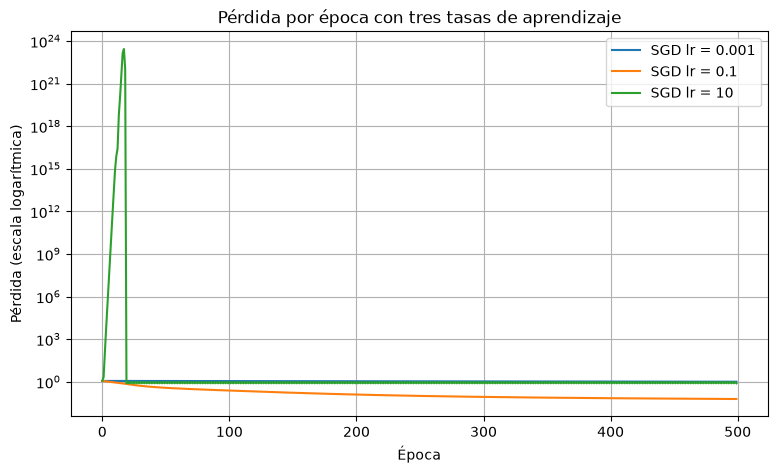

In [17]:
# celda 17

plt.figure(figsize=(9, 5))

for tasa in tasas_aprendizaje:
    plt.plot(historiales_sgd[tasa], label=f'SGD lr = {tasa}')

plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Pérdida (escala logarítmica)')
plt.title('Pérdida por época con tres tasas de aprendizaje')
plt.legend()
plt.grid(True)
plt.show()


Mejor tasa de SGD: 0.1
Pérdida final SGD: 0.0615
Pérdida final Adam: 0.2202


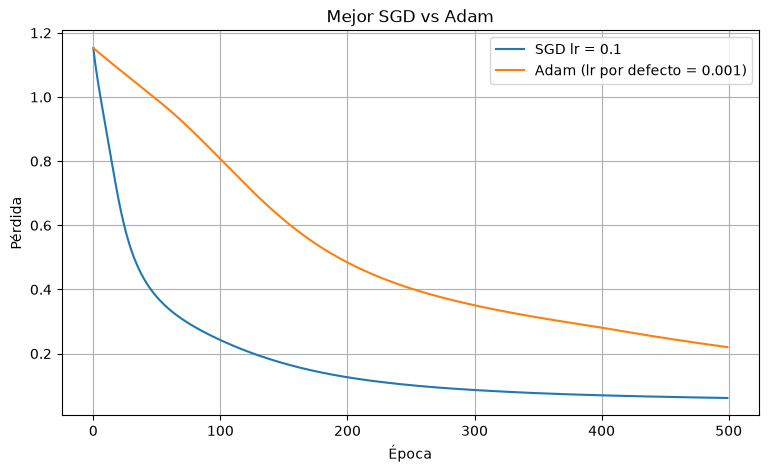

In [ ]:
# celda 18


mejor_tasa_sgd = min(
    tasas_aprendizaje,
    key=lambda tasa: np.nan_to_num(historiales_sgd[tasa][-1], nan=np.inf)
)

torch.manual_seed(42)
modelo_adam = MLPIris()
optimizador_adam = torch.optim.Adam(modelo_adam.parameters())

historial_adam = entrenar_iris(modelo_adam, optimizador_adam)

print("Mejor tasa de SGD:", mejor_tasa_sgd)
print("Pérdida final SGD:", round(historiales_sgd[mejor_tasa_sgd][-1], 4))
print("Pérdida final Adam:", round(historial_adam[-1], 4))

plt.figure(figsize=(9, 5))
plt.plot(historiales_sgd[mejor_tasa_sgd], label=f'SGD lr = {mejor_tasa_sgd}')
plt.plot(historial_adam, label='Adam (lr por defecto = 0.001)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Mejor SGD vs Adam')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# celda 19


modelos_iris = {f'SGD lr={tasa}': modelos_sgd[tasa] for tasa in tasas_aprendizaje}
modelos_iris['Adam lr=0.001'] = modelo_adam

historiales_iris = {f'SGD lr={tasa}': historiales_sgd[tasa] for tasa in tasas_aprendizaje}
historiales_iris['Adam lr=0.001'] = historial_adam

resultados_iris = {}

for nombre, modelo in modelos_iris.items():
    exactitud, _ = evaluar_modelo(modelo)
    resultados_iris[nombre] = {
        'Pérdida final (entrenamiento)': round(historiales_iris[nombre][-1], 4),
        'Exactitud en validación': round(exactitud, 4)
    }

tabla_resultados_iris = pd.DataFrame(resultados_iris).T
display(tabla_resultados_iris)


nombre_mejor_modelo = max(
    resultados_iris,
    key=lambda nombre: (
        resultados_iris[nombre]['Exactitud en validación'],
        -np.nan_to_num(resultados_iris[nombre]['Pérdida final (entrenamiento)'], nan=np.inf)
    )
)

print()
print("Mejor modelo:", nombre_mejor_modelo)


,Pérdida final (entrenamiento),Exactitud en validación
SGD lr=0.001,1.0153,0.7000
SGD lr=0.1,0.0615,0.9667
SGD lr=10,0.7824,0.7000
Adam lr=0.001,0.2202,0.9000



Mejor modelo: SGD lr=0.1


Exactitud final en validación (SGD lr=0.1): 96.67%



,Predicho: setosa,Predicho: versicolor,Predicho: virginica
Real: setosa,10,0,0
Real: versicolor,0,9,1
Real: virginica,0,0,10


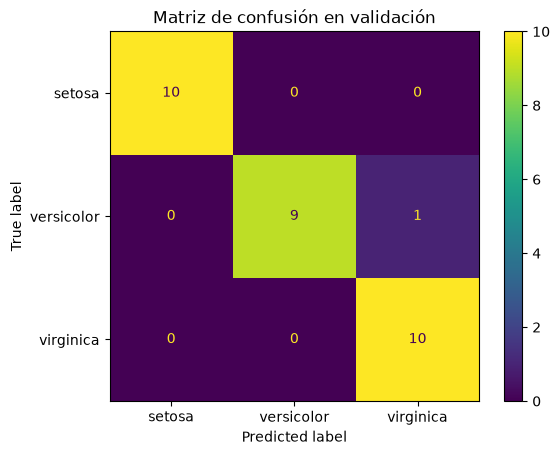


Confusiones entre setosa y versicolor: 0
Confusiones entre setosa y virginica: 0
Confusiones entre versicolor y virginica: 1


In [ ]:
# celda 20

mejor_modelo_iris = modelos_iris[nombre_mejor_modelo]

exactitud_final, predicciones_validacion = evaluar_modelo(mejor_modelo_iris)

print(f"Exactitud final en validación ({nombre_mejor_modelo}): {exactitud_final * 100:.2f}%")

matriz_confusion = confusion_matrix(
    etiquetas_validacion.numpy(),
    predicciones_validacion.numpy()
)

tabla_confusion = pd.DataFrame(
    matriz_confusion,
    index=[f'Real: {nombre}' for nombre in nombres_especies],
    columns=[f'Predicho: {nombre}' for nombre in nombres_especies]
)

print()
display(tabla_confusion)

ConfusionMatrixDisplay(matriz_confusion, display_labels=nombres_especies).plot()
plt.title('Matriz de confusión en validación')
plt.show()


print()
for i in range(3):
    for j in range(i + 1, 3):
        total_confusiones = matriz_confusion[i, j] + matriz_confusion[j, i]
        print(f"Confusiones entre {nombres_especies[i]} y {nombres_especies[j]}: {total_confusiones}")


### Parámetros del MLP de Iris

El MLP utilizado para Iris tiene 4 neuronas de entrada, una capa oculta de 8 neuronas y una capa de salida con 3 neuronas, una para cada especie.

En total el modelo tiene 67 parámetros entrenables. La primera capa tiene 4 × 8 = 32 pesos y 8 sesgos, mientras que la capa de salida tiene 8 × 3 = 24 pesos y 3 sesgos. Por lo tanto:

32 + 8 + 24 + 3 = 67 parámetros


### ¿Por qué no se pone softmax en la última capa con nn.CrossEntropyLoss?

No se coloca softmax directamente en la última capa porque nn.CrossEntropyLoss espera recibir los logits originales que produce la red.

Internamente, CrossEntropyLoss ya se encarga de transformar esos logits para calcular la pérdida de clasificación. Entonces, si se aplicara softmax manualmente antes de pasar los resultados a la función de pérdida, básicamente estaríamos haciendo una transformación que no es necesaria.

Por eso la última capa del modelo únicamente devuelve los tres logits y CrossEntropyLoss se encarga del resto durante el entrenamiento.


### Comparación de las tres tasas de aprendizaje

Las tres tasas de aprendizaje tuvieron comportamientos bastante diferentes.

Con lr=0.001, la pérdida comenzó en 1.1529 y después de 500 épocas solamente bajó hasta 1.0153. La exactitud en validación fue de 70%. Entonces esta tasa sí está aprendiendo, pero demasiado lento para la cantidad de épocas utilizadas.

Con lr=0.1 el comportamiento fue mucho mejor. La pérdida bajó desde 1.1529 hasta 0.0615 y obtuvo una exactitud de 96.67% en validación. Esta fue claramente la tasa que logró converger correctamente.

Por último, con lr=10 se puede ver en la gráfica que la pérdida se dispara durante las primeras épocas hasta valores extremadamente grandes. Después vuelve a bajar y termina en 0.7824, pero solamente logra 70% de exactitud. Por lo tanto, esta tasa es demasiado grande y hace que el entrenamiento sea muy inestable. Los pasos que hace SGD son tan grandes que sobrepasa constantemente una buena solución, por eso es el ejemplo de la tasa que diverge.


### Adam vs el mejor SGD

La mejor tasa de SGD fue lr=0.1, que terminó con una pérdida de 0.0615. Adam utilizando su tasa por defecto de 0.001 terminó con una pérdida de 0.2202.

También se puede ver la diferencia en validación. SGD con lr=0.1 obtuvo 96.67% de exactitud, mientras que Adam obtuvo 90%.

En este caso específico Adam no logró superar al mejor SGD. Esto no significa que SGD siempre vaya a ser mejor que Adam, sino que para este modelo y estos datos la tasa de 0.1 de SGD funcionó mejor con las 500 épocas utilizadas.


### Exactitud en validación y matriz de confusión

El mejor modelo fue SGD con una tasa de aprendizaje de 0.1 y obtuvo una exactitud final de 96.67% en validación.

La matriz de confusión muestra que las 10 flores de la especie setosa fueron clasificadas correctamente y también las 10 virginica. El único error ocurrió con una flor de la especie versicolor, que fue clasificada como virginica.

Por lo tanto, el par de especies que más confundió el modelo fue versicolor y virginica, con una confusión en total. Esto también tiene sentido viendo la matriz, ya que setosa quedó completamente separada de las otras dos especies.

# Sección 4: redes recurrentes para etiquetado POS

In [21]:
# celda 21

nltk.download('treebank')
nltk.download('universal_tagset')

from nltk.corpus import treebank

oraciones_etiquetadas = list(treebank.tagged_sents(tagset='universal'))

oraciones_entrenamiento, oraciones_prueba = train_test_split(
    oraciones_etiquetadas,
    test_size=0.2,
    random_state=42
)

print("Oraciones totales:", len(oraciones_etiquetadas))
print("Oraciones de entrenamiento:", len(oraciones_entrenamiento))
print("Oraciones de prueba:", len(oraciones_prueba))
print()
print("Ejemplo:", oraciones_etiquetadas[0][:8])


[nltk_data] Downloading package treebank to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


Oraciones totales: 3914
Oraciones de entrenamiento: 3131
Oraciones de prueba: 783

Ejemplo: [('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), (',', '.'), ('will', 'VERB')]


In [ ]:
# celda 22


FRECUENCIA_MINIMA = 2

conteo_palabras = Counter(
    palabra.lower()
    for oracion in oraciones_entrenamiento
    for palabra, _ in oracion
)

palabra_a_indice = {'<PAD>': 0, '<UNK>': 1}


for palabra, frecuencia in conteo_palabras.items():
    if frecuencia >= FRECUENCIA_MINIMA:
        palabra_a_indice[palabra] = len(palabra_a_indice)

indice_relleno_palabras = palabra_a_indice['<PAD>']
indice_desconocida = palabra_a_indice['<UNK>']

etiquetas_unicas = sorted({
    etiqueta
    for oracion in oraciones_etiquetadas
    for _, etiqueta in oracion
})

etiqueta_a_indice = {'<PAD>': 0}
for etiqueta in etiquetas_unicas:
    etiqueta_a_indice[etiqueta] = len(etiqueta_a_indice)

indice_a_etiqueta = {indice: etiqueta for etiqueta, indice in etiqueta_a_indice.items()}
indice_relleno_etiquetas = etiqueta_a_indice['<PAD>']

print("Palabras distintas en entrenamiento:", len(conteo_palabras))
print("Tamaño del vocabulario (con frecuencia mínima 2):", len(palabra_a_indice))
print("Etiquetas:", list(etiqueta_a_indice.keys()))


Palabras distintas en entrenamiento: 10138
Tamaño del vocabulario (con frecuencia mínima 2): 4844
Etiquetas: ['<PAD>', '.', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']


In [ ]:
# celda 23

def convertir_oracion(oracion):
    indices_palabras = torch.tensor([
        palabra_a_indice.get(palabra.lower(), indice_desconocida)
        for palabra, _ in oracion
    ])

    indices_etiquetas = torch.tensor([
        etiqueta_a_indice[etiqueta]
        for _, etiqueta in oracion
    ])

    return indices_palabras, indices_etiquetas


def armar_lote(lote):
    palabras = pad_sequence(
        [palabras_oracion for palabras_oracion, _ in lote],
        batch_first=True,
        padding_value=indice_relleno_palabras
    )

    etiquetas = pad_sequence(
        [etiquetas_oracion for _, etiquetas_oracion in lote],
        batch_first=True,
        padding_value=indice_relleno_etiquetas
    )

    return palabras, etiquetas


datos_entrenamiento = [convertir_oracion(oracion) for oracion in oraciones_entrenamiento]
datos_prueba = [convertir_oracion(oracion) for oracion in oraciones_prueba]


def nuevo_cargador_entrenamiento():
  
    return DataLoader(
        datos_entrenamiento,
        batch_size=32,
        shuffle=True,
        collate_fn=armar_lote,
        generator=torch.Generator().manual_seed(42)
    )


cargador_prueba = DataLoader(
    datos_prueba,
    batch_size=32,
    shuffle=False,
    collate_fn=armar_lote
)

palabras_ejemplo, etiquetas_ejemplo = next(iter(nuevo_cargador_entrenamiento()))
print("Forma de un lote de palabras:", tuple(palabras_ejemplo.shape))
print("Forma de un lote de etiquetas:", tuple(etiquetas_ejemplo.shape))


Forma de un lote de palabras: (32, 67)
Forma de un lote de etiquetas: (32, 67)


In [ ]:
# celda 24

DIMENSION_EMBEDDING = 100
DIMENSION_OCULTA = 128


class EtiquetadorPOS(nn.Module):

    def __init__(self, tamano_vocabulario, dimension_embedding, dimension_oculta,
                 numero_etiquetas, tipo_recurrente='lstm'):
        super().__init__()

        self.embedding = nn.Embedding(
            tamano_vocabulario,
            dimension_embedding,
            padding_idx=indice_relleno_palabras
        )

        if tipo_recurrente == 'lstm':
            self.recurrente = nn.LSTM(dimension_embedding, dimension_oculta, batch_first=True)
        else:
            self.recurrente = nn.RNN(dimension_embedding, dimension_oculta, batch_first=True)

        self.capa_salida = nn.Linear(dimension_oculta, numero_etiquetas)

    def forward(self, palabras):
        vectores = self.embedding(palabras)
        salida_recurrente, _ = self.recurrente(vectores)

        return self.capa_salida(salida_recurrente)


In [ ]:
# celda 25

EPOCAS_POS = 10


def entrenar_etiquetador(modelo, epocas=EPOCAS_POS, tasa_aprendizaje=0.005):
    cargador_entrenamiento = nuevo_cargador_entrenamiento()

    # ignore_index hace que el relleno no cuente en la pérdida
    funcion_perdida = nn.CrossEntropyLoss(ignore_index=indice_relleno_etiquetas)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=tasa_aprendizaje)

    historial_perdida = []

    for epoca in range(epocas):
        modelo.train()
        perdida_total = 0

        for palabras, etiquetas in cargador_entrenamiento:
            salida = modelo(palabras)


            perdida = funcion_perdida(
                salida.reshape(-1, salida.shape[-1]),
                etiquetas.reshape(-1)
            )

            optimizador.zero_grad()
            perdida.backward()
            optimizador.step()

            perdida_total += perdida.item()

        perdida_promedio = perdida_total / len(cargador_entrenamiento)
        historial_perdida.append(perdida_promedio)
        print(f"Época {epoca + 1}/{epocas} - pérdida: {perdida_promedio:.4f}")

    return historial_perdida


def exactitud_por_token(modelo, cargador):
    modelo.eval()
    aciertos = 0
    total = 0

    with torch.no_grad():
        for palabras, etiquetas in cargador:
            predicciones = modelo(palabras).argmax(dim=2)

            no_es_relleno = etiquetas != indice_relleno_etiquetas

            aciertos += ((predicciones == etiquetas) & no_es_relleno).sum().item()
            total += no_es_relleno.sum().item()

    return aciertos / total


In [ ]:
# celda 26


torch.manual_seed(42)
modelo_lstm = EtiquetadorPOS(
    len(palabra_a_indice), DIMENSION_EMBEDDING, DIMENSION_OCULTA,
    len(etiqueta_a_indice), tipo_recurrente='lstm'
)

print("Parámetros del LSTM:", contar_parametros(modelo_lstm))
historial_lstm = entrenar_etiquetador(modelo_lstm)

exactitud_lstm = exactitud_por_token(modelo_lstm, cargador_prueba)
print()
print(f"Exactitud por token del LSTM en prueba: {exactitud_lstm * 100:.2f}%")


Parámetros del LSTM: 603837
Época 1/10 - pérdida: 0.7885
Época 2/10 - pérdida: 0.2510
Época 3/10 - pérdida: 0.1427
Época 4/10 - pérdida: 0.0983
Época 5/10 - pérdida: 0.0734
Época 6/10 - pérdida: 0.0556
Época 7/10 - pérdida: 0.0423
Época 8/10 - pérdida: 0.0317
Época 9/10 - pérdida: 0.0248
Época 10/10 - pérdida: 0.0181

Exactitud por token del LSTM en prueba: 93.97%


Parámetros de la RNN: 515517
Época 1/10 - pérdida: 0.7515
Época 2/10 - pérdida: 0.2823
Época 3/10 - pérdida: 0.1675
Época 4/10 - pérdida: 0.1216
Época 5/10 - pérdida: 0.0967
Época 6/10 - pérdida: 0.0812
Época 7/10 - pérdida: 0.0693
Época 8/10 - pérdida: 0.0570
Época 9/10 - pérdida: 0.0469
Época 10/10 - pérdida: 0.0414

Exactitud por token de la RNN en prueba: 93.51%



,Modelo,Parámetros,Exactitud por token (prueba)
0,LSTM,603837,93.97
1,RNN,515517,93.51


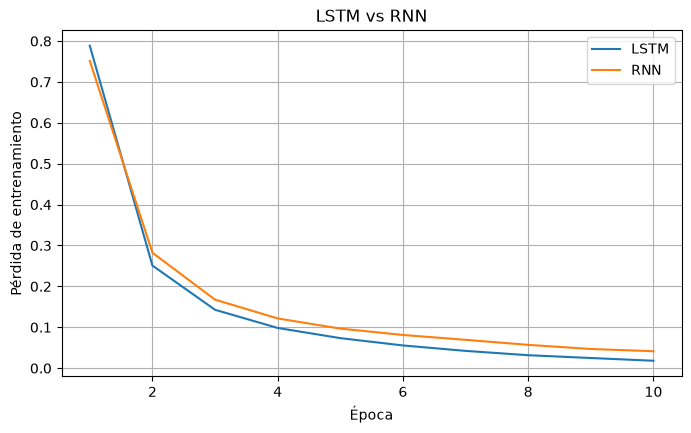

Mejor modelo de POS: LSTM


In [ ]:
# celda 27


torch.manual_seed(42)
modelo_rnn = EtiquetadorPOS(
    len(palabra_a_indice), DIMENSION_EMBEDDING, DIMENSION_OCULTA,
    len(etiqueta_a_indice), tipo_recurrente='rnn'
)

print("Parámetros de la RNN:", contar_parametros(modelo_rnn))
historial_rnn = entrenar_etiquetador(modelo_rnn)

exactitud_rnn = exactitud_por_token(modelo_rnn, cargador_prueba)
print()
print(f"Exactitud por token de la RNN en prueba: {exactitud_rnn * 100:.2f}%")

tabla_exactitudes = pd.DataFrame({
    'Modelo': ['LSTM', 'RNN'],
    'Parámetros': [contar_parametros(modelo_lstm), contar_parametros(modelo_rnn)],
    'Exactitud por token (prueba)': [round(exactitud_lstm * 100, 2), round(exactitud_rnn * 100, 2)]
})

print()
display(tabla_exactitudes)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, EPOCAS_POS + 1), historial_lstm, label='LSTM')
plt.plot(range(1, EPOCAS_POS + 1), historial_rnn, label='RNN')
plt.xlabel('Época')
plt.ylabel('Pérdida de entrenamiento')
plt.title('LSTM vs RNN')
plt.legend()
plt.grid(True)
plt.show()

if exactitud_lstm >= exactitud_rnn:
    mejor_modelo_pos = modelo_lstm
    nombre_mejor_modelo_pos = 'LSTM'
else:
    mejor_modelo_pos = modelo_rnn
    nombre_mejor_modelo_pos = 'RNN'

print("Mejor modelo de POS:", nombre_mejor_modelo_pos)


In [ ]:
# celda 28


def predecir_etiquetas(modelo, palabras):
    modelo.eval()

    indices = torch.tensor([[
        palabra_a_indice.get(palabra.lower(), indice_desconocida)
        for palabra in palabras
    ]])

    with torch.no_grad():
        salida = modelo(indices)

    indices_predichos = salida.argmax(dim=2)[0].tolist()

    return [indice_a_etiqueta[indice] for indice in indices_predichos]


oraciones_ambiguas = [
    "I want to book a flight to Boston",
    "She read a good book last night",
    "Please book the room for tomorrow",
    "They run every morning before work",
    "The company had a good run this year",
    "He will run the company next year"
]

print("Modelo usado:", nombre_mejor_modelo_pos)
print()

for oracion in oraciones_ambiguas:
    palabras = re.findall(r"\w+|[^\w\s]", oracion)
    etiquetas_predichas = predecir_etiquetas(mejor_modelo_pos, palabras)

    print(" ".join(f"{palabra}/{etiqueta}" for palabra, etiqueta in zip(palabras, etiquetas_predichas)))

    palabras_desconocidas = [
        palabra for palabra in palabras
        if palabra.lower() not in palabra_a_indice
    ]
    print("  Palabras desconocidas para el modelo:", palabras_desconocidas)
    print()


Modelo usado: LSTM

I/PRON want/VERB to/PRT book/NOUN a/DET flight/NOUN to/PRT Boston/NOUN
  Palabras desconocidas para el modelo: ['flight']

She/PRON read/VERB a/DET good/ADJ book/NOUN last/ADJ night/NOUN
  Palabras desconocidas para el modelo: []

Please/NOUN book/NOUN the/DET room/NOUN for/ADP tomorrow/NOUN
  Palabras desconocidas para el modelo: ['Please', 'room']

They/PRON run/VERB every/DET morning/NOUN before/ADP work/NOUN
  Palabras desconocidas para el modelo: []

The/DET company/NOUN had/VERB a/DET good/ADJ run/NOUN this/DET year/NOUN
  Palabras desconocidas para el modelo: []

He/PRON will/VERB run/VERB the/DET company/NOUN next/ADP year/NOUN
  Palabras desconocidas para el modelo: []



In [ ]:
# celda 29

nlp_modelo = spacy.load('en_core_web_sm', exclude=['parser', 'ner', 'lemmatizer'])

etiquetas_reales = []
etiquetas_modelo_neuronal = []
etiquetas_spacy = []

for oracion in oraciones_prueba:
    palabras = [palabra for palabra, _ in oracion]

    etiquetas_reales += [etiqueta for _, etiqueta in oracion]
    etiquetas_modelo_neuronal += predecir_etiquetas(mejor_modelo_pos, palabras)

    doc = nlp_modelo(Doc(nlp_modelo.vocab, words=palabras))


    etiquetas_spacy += [nltk.tag.map_tag('en-ptb', 'universal', token.tag_) for token in doc]

etiquetas_reales = np.array(etiquetas_reales)
etiquetas_modelo_neuronal = np.array(etiquetas_modelo_neuronal)
etiquetas_spacy = np.array(etiquetas_spacy)

mascara_sin_x = etiquetas_reales != 'X'

print("Tokens de prueba:", len(etiquetas_reales))
print(f"Porcentaje de tokens con etiqueta X: {(~mascara_sin_x).mean() * 100:.2f}%")
print()

comparacion_taggers = pd.DataFrame({
    'Tagger': [f'{nombre_mejor_modelo_pos} (PyTorch)', 'spaCy en_core_web_sm'],
    'Exactitud todos los tokens (%)': [
        round((etiquetas_modelo_neuronal == etiquetas_reales).mean() * 100, 2),
        round((etiquetas_spacy == etiquetas_reales).mean() * 100, 2)
    ],
    'Exactitud sin tokens X (%)': [
        round((etiquetas_modelo_neuronal[mascara_sin_x] == etiquetas_reales[mascara_sin_x]).mean() * 100, 2),
        round((etiquetas_spacy[mascara_sin_x] == etiquetas_reales[mascara_sin_x]).mean() * 100, 2)
    ]
})

display(comparacion_taggers)


Tokens de prueba: 20549
Porcentaje de tokens con etiqueta X: 6.62%



,Tagger,Exactitud todos los tokens (%),Exactitud sin tokens X (%)
0,LSTM (PyTorch),93.97,93.73
1,spaCy en_core_web_sm,91.87,96.66


In [ ]:
# celda 30

def exactitud_conocidas_y_desconocidas(modelo, cargador):
    modelo.eval()

    aciertos_conocidas = 0
    total_conocidas = 0
    aciertos_desconocidas = 0
    total_desconocidas = 0

    with torch.no_grad():
        for palabras, etiquetas in cargador:
            predicciones = modelo(palabras).argmax(dim=2)
            acierta = predicciones == etiquetas

            no_es_relleno = etiquetas != indice_relleno_etiquetas
            es_desconocida = (palabras == indice_desconocida) & no_es_relleno
            es_conocida = (palabras != indice_desconocida) & no_es_relleno

            aciertos_conocidas += (acierta & es_conocida).sum().item()
            total_conocidas += es_conocida.sum().item()
            aciertos_desconocidas += (acierta & es_desconocida).sum().item()
            total_desconocidas += es_desconocida.sum().item()

    return aciertos_conocidas, total_conocidas, aciertos_desconocidas, total_desconocidas


(aciertos_conocidas, total_conocidas,
 aciertos_desconocidas, total_desconocidas) = exactitud_conocidas_y_desconocidas(
    mejor_modelo_pos, cargador_prueba
)

total_tokens_prueba = total_conocidas + total_desconocidas

print(f"Tokens desconocidos en prueba: {total_desconocidas} de {total_tokens_prueba} "
      f"({total_desconocidas / total_tokens_prueba * 100:.2f}%)")
print(f"Exactitud en palabras conocidas: {aciertos_conocidas / total_conocidas * 100:.2f}%")
print(f"Exactitud en palabras desconocidas: {aciertos_desconocidas / total_desconocidas * 100:.2f}%")


Tokens desconocidos en prueba: 2134 de 20549 (10.38%)
Exactitud en palabras conocidas: 97.19%
Exactitud en palabras desconocidas: 66.21%


### Exactitud del LSTM y de la RNN

Después de entrenar ambos modelos durante 10 épocas, los resultados fueron los siguientes:

| Modelo | Parámetros | Exactitud por token en prueba |
|---|---:|---:|
| LSTM | 603837 | 93.97% |
| RNN | 515517 | 93.51% |

Los dos modelos tuvieron resultados bastante parecidos, pero el LSTM fue ligeramente mejor con una exactitud de 93.97% comparado con 93.51% de la RNN.

También se puede observar que el LSTM tiene más parámetros que la RNN, 603837 contra 515517. Esto se debe a que la arquitectura del LSTM es más compleja y utiliza mecanismos adicionales para controlar qué información conserva o descarta de la secuencia.

Por esta razón se utilizó el LSTM como el mejor modelo para las siguientes pruebas.


### Oraciones ambiguas: ¿el contexto resuelve la ambigüedad?

Los resultados muestran que el contexto sí ayuda al modelo a resolver algunas palabras ambiguas, pero no lo hace correctamente en todos los casos.

Con la palabra run, el modelo sí logró utilizar bastante bien el contexto. En "They run every morning before work" etiquetó run como VERB, en "The company had a good run this year" la etiquetó como NOUN y en "He will run the company next year" volvió a etiquetarla como VERB. Entonces, para esta palabra sí logró cambiar la categoría dependiendo de las palabras que tenía alrededor.

Con book el resultado no fue tan bueno. En "She read a good book last night" correctamente identificó book como NOUN. Sin embargo, en "I want to book a flight to Boston" y "Please book the room for tomorrow" también predijo NOUN cuando en esos dos casos debería funcionar como verbo.

Por lo tanto, el contexto sí está ayudando al LSTM, como se puede ver claramente con run, pero no significa que siempre sea suficiente para resolver cualquier ambigüedad. En el caso de book el modelo parece haber aprendido una preferencia bastante fuerte hacia la etiqueta NOUN.

También hay que tomar en cuenta que algunas palabras de estas oraciones, como flight, Please y room, fueron palabras desconocidas para el vocabulario del modelo, lo cual también puede afectar el contexto disponible para hacer la predicción.


### Comparación con el tagger del Laboratorio 6

Al comparar el LSTM con el tagger de spaCy los resultados inicialmente fueron estos:

| Tagger | Exactitud todos los tokens | Exactitud sin tokens X |
|---|---:|---:|
| LSTM (PyTorch) | 93.97% | 93.73% |
| spaCy en_core_web_sm | 91.87% | 96.66% |

Si se utilizan todos los tokens, el LSTM parece tener una mejor exactitud, con 93.97% comparado con 91.87% de spaCy. Sin embargo, el 6.62% de los tokens de prueba tienen la etiqueta X, que en Treebank incluye varios símbolos o elementos especiales.

Cuando se eliminan esos tokens X de la comparación, spaCy obtiene 96.66% mientras que el LSTM obtiene 93.73%. Entonces esta comparación muestra que parte de la diferencia inicial viene de cómo cada modelo maneja esas etiquetas especiales.

También hay una diferencia importante en los datos y en la forma en que fueron entrenados. Mi LSTM se entrenó desde cero únicamente con 3131 oraciones de entrenamiento del Treebank y sus embeddings también se aprendieron durante este entrenamiento. spaCy, por otro lado, ya es un modelo entrenado previamente y está mucho más optimizado para hacer etiquetado gramatical.

Por lo tanto, tiene sentido que al hacer una comparación más limpia sin los tokens X, spaCy tenga mejor desempeño. Aun así, obtener alrededor de 94% con un LSTM entrenado solamente con este corpus demuestra que la arquitectura logró aprender bastante bien las relaciones entre las palabras y sus etiquetas.

# Sección 9: conclusiones

In [ ]:
# celda 31

tamano_vocabulario = len(palabra_a_indice)
indice_company = palabra_a_indice['company']

vector_one_hot = torch.nn.functional.one_hot(
    torch.tensor(indice_company),
    num_classes=tamano_vocabulario
)

with torch.no_grad():
    vector_embedding = mejor_modelo_pos.embedding(torch.tensor(indice_company))

print("Palabra de ejemplo: company")
print()
print("One-hot:")
print("  Tamaño del vector:", vector_one_hot.shape[0])
print("  Valores distintos de cero:", vector_one_hot.sum().item())
print()
print("Embedding:")
print("  Tamaño del vector:", vector_embedding.shape[0])
print("  Primeros 5 valores:", [round(valor, 3) for valor in vector_embedding[:5].tolist()])


Palabra de ejemplo: company

One-hot:
  Tamaño del vector: 4844
  Valores distintos de cero: 1

Embedding:
  Tamaño del vector: 100
  Primeros 5 valores: [0.111, -0.929, -0.674, -0.316, -0.565]


In [ ]:
# celda 32

from importlib.metadata import version, PackageNotFoundError

paquetes_usados = ['torch', 'nltk', 'gensim', 'numpy', 'pandas',
                   'matplotlib', 'scikit-learn', 'spacy']

with open('requirements.txt', 'w') as archivo_requisitos:
    for paquete in paquetes_usados:
        try:
            archivo_requisitos.write(f"{paquete}=={version(paquete)}\n")
            print(f"{paquete}=={version(paquete)}")
        except PackageNotFoundError:
            print(f"{paquete} no está instalado (instalalo con pip y volvé a correr esta celda)")


torch==2.14.1
nltk==3.10.0
gensim==4.4.0
numpy==2.5.1
pandas==3.0.5
matplotlib==3.11.1
scikit-learn==1.9.0
spacy==3.8.14


### ¿Por qué fue tan importante el caso XOR y qué ingrediente permitió resolverlo?

El caso XOR fue importante porque demostró una limitación bastante clara de los modelos lineales. Un perceptrón de una sola capa no puede resolver XOR porque los puntos no se pueden separar correctamente utilizando una sola línea.

En este laboratorio se pudo comprobar directamente. Cuando se utilizó el MLP con tanh, el modelo llegó a 100% de exactitud. Sin embargo, al quitar la función de activación la exactitud bajó a 75% y las cuatro entradas recibieron una probabilidad de aproximadamente 0.5.

Entonces no basta únicamente con agregar más capas. Si todas las capas son lineales, se pueden combinar y siguen siendo equivalentes a una sola capa lineal. El ingrediente realmente importante es introducir una activación no lineal entre las capas, ya que eso permite que la red aprenda una frontera de decisión que no sea una simple línea. En ese sentido se necesitan las capas para construir la red, pero la activación no lineal es lo que realmente permite resolver XOR.


### One-hot vs TF-IDF / bag-of-words vs embeddings densos

One-hot, Bag of Words y TF-IDF tienen en común que producen representaciones bastante dispersas. En one-hot, por ejemplo, cada palabra tiene un vector del tamaño completo del vocabulario donde solamente una posición tiene valor 1 y todas las demás son 0.

Esto se puede ver en el ejemplo de company. El vocabulario utilizado tiene 4844 posiciones, entonces su representación one-hot tiene tamaño 4844 pero solamente 1 valor diferente de cero. Por otro lado, el embedding aprendido por el LSTM representa la misma palabra utilizando solamente 100 valores, y todos estos valores pueden contener información.

Con Bag of Words y TF-IDF pasa algo parecido a lo que vimos en laboratorios anteriores. Cada documento queda representado con respecto al vocabulario completo, por lo que los vectores pueden tener miles de posiciones y la mayoría quedan en cero. Además, estas representaciones indican principalmente presencia, frecuencia o importancia de las palabras, pero no aprenden directamente una representación de su significado.

Los embeddings tienen la ventaja de ser vectores densos y de menor dimensión que se aprenden durante el entrenamiento. Por lo tanto, el modelo puede modificar estos vectores de acuerdo con los contextos donde aparece cada palabra, en lugar de tratar cada palabra como una posición completamente independiente.

Sin embargo, utilizar embeddings de palabras completas no elimina por completo el problema de OOV. Si aparece una palabra que nunca estuvo en el vocabulario de entrenamiento, nuestro modelo no tiene un embedding específico para ella y tiene que convertirla en <UNK>.


### ¿Cómo maneja mi LSTM las palabras desconocidas y cómo se podría mejorar?

Mi LSTM utiliza un token especial <UNK> para manejar las palabras desconocidas. Además, durante la creación del vocabulario se dejaron fuera las palabras que aparecían solamente una vez en entrenamiento, de manera que también se convirtieran en <UNK> y el modelo pudiera aprender un embedding para este token durante el entrenamiento.

En el conjunto de prueba hubo 2134 tokens desconocidos de 20549, lo cual representa aproximadamente 10.38% de todos los tokens.

La diferencia de desempeño entre palabras conocidas y desconocidas fue bastante grande. Para las palabras conocidas el modelo obtuvo una exactitud de 97.19%, mientras que para las palabras desconocidas obtuvo solamente 66.21%.

Tiene sentido que esto pase porque todas las palabras desconocidas terminan compartiendo exactamente el mismo embedding de <UNK>. Osea que para el modelo una palabra desconocida pierde su identidad y solamente puede tratar de adivinar su categoría usando el contexto de las palabras que tiene alrededor.

Una forma de mejorar esto sería utilizar representación por subpalabras en lugar de trabajar únicamente con palabras completas. De esa forma, una palabra nueva podría dividirse en partes que el modelo ya conoce en vez de convertirse completamente en <UNK>. Otra posibilidad sería utilizar embeddings preentrenados para comenzar con representaciones que ya hayan aprendido información de un corpus mucho más grande.